# Projeto QSAR com CNN: Dataset BACE_C
## Classificação binária de inibidores da enzima BACE-1 via imagens moleculares

**Dataset:** BACE_C — tarefa: prever se um composto é inibidor da β-secretase (BACE-1)  
**Rótulos:** `class_0` = não inibidor | `class_1` = inibidor da BACE-1  

Este notebook implementa e compara duas abordagens de classificação binária:
- **Baseline:** CNN construída do zero com 3 blocos convolucionais
- **Fine-tuning:** MobileNetV2 pré-treinado no ImageNet com descongelamento parcial
## 1. Importações e configuração global

### Semente aleatória (Requisito Técnico 3)
`tf.keras.utils.set_random_seed(42)` configura simultaneamente as sementes do
TensorFlow, NumPy e do módulo `random` do Python — garantindo reprodutibilidade
completa sem precisar chamar cada biblioteca separadamente.

### Hiperparâmetros globais
| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `SEED` | `42` | Valor padrão amplamente adotado; facilita comparação com literatura |
| `IMG_SIZE` | `(224, 224)` | Resolução mínima esperada pelo MobileNetV2 (treinado em 224×224 no ImageNet); mantida igual na baseline para comparação justa |
| `BATCH_SIZE` | `32` | Equilíbrio entre estabilidade do gradiente e uso de memória; funciona bem em GPUs com 8–16 GB VRAM para imagens 224×224 RGB |

In [1]:
import os
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2


# Define o nome do dataset atual como BACE_C
DATASET_ATUAL = "BACE_C"

# Cria a pasta de resultados principal
pasta_resultados = f"resultados_{DATASET_ATUAL}"
os.makedirs(pasta_resultados, exist_ok=True)

print(f"Pasta de logs criada em: {pasta_resultados}/")

# REQUISITO TÉCNICO 3: Fixar a mesma semente aleatória para reprodutibilidade
SEED = 42
tf.keras.utils.set_random_seed(SEED)

print("Versão do TensorFlow:", tf.__version__)
print("GPU Disponível:", tf.config.list_physical_devices('GPU'))

Pasta de logs criada em: resultados_BACE_C/
Versão do TensorFlow: 2.10.0
GPU Disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carregamento dos dados

`tf.keras.utils.image_dataset_from_directory` lê as imagens diretamente das
subpastas `class_0/` e `class_1/`, atribuindo rótulos automaticamente pela
ordem lexicográfica (`class_0 → 0`, `class_1 → 1`).

### Decisões de configuração
| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `image_size` | `(224, 224)` | Igual ao `IMG_SIZE` global; redimensiona automaticamente qualquer imagem do dataset |
| `batch_size` | `32` | Mesmo valor para treino, validação e teste — comparação justa entre modelos |
| `label_mode` | `'binary'` | Gera rótulos float no formato `[[0.], [1.]]`, compatível com `sigmoid` + `binary_crossentropy` |
| `shuffle=False` (teste) | — | Essencial: sem shuffle o teste preserva a ordem original, permitindo alinhar `y_true` com `y_pred` durante a avaliação |

In [2]:
# Configuração de dimensões padrão
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Caminhos exatos do diretório
train_dir = 'dataset_bace_c/train/'
val_dir   = 'dataset_bace_c/val/'
test_dir  = 'dataset_bace_c/test/'

# Criando os geradores de dados nativos
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("Dados do BACE_C carregados com sucesso!")

Found 1215 files belonging to 2 classes.
Found 165 files belonging to 2 classes.
Found 133 files belonging to 2 classes.
Dados do BACE_C carregados com sucesso!


## 3. Otimização do pipeline de dados

`prefetch(AUTOTUNE)` sobrepõe o carregamento do próximo batch com o processamento
do batch atual na GPU, eliminando tempo ocioso de I/O. `AUTOTUNE` deixa o TensorFlow
determinar dinamicamente o número ideal de elementos a pré-carregar.

In [3]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset   = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset  = test_dataset.prefetch(buffer_size=AUTOTUNE)
print("Pipeline otimizado com prefetch!")

Pipeline otimizado com prefetch!


## 4. Callbacks de monitoramento (Requisitos Técnicos 5 e 6.3)

### TimeHistory — medição de tempo por época
Callback customizado que registra `time.time()` no início e no fim de cada época.
Permite calcular tempo médio por época e tempo total real (considerando early stopping),
conforme exigido pelo Requisito 6.3.

### EarlyStopping
| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `monitor` | `'val_loss'` | Loss de validação é o indicador mais direto de generalização; AUC seria alternativa válida, mas val_loss é mais sensível a pequenas oscilações |
| `patience` | `10` | Permite que o modelo supere platôs temporários sem interromper prematuramente; com datasets moleculares pequenos, 5 épocas podem ser insuficientes |
| `restore_best_weights` | `True` | Garante que o modelo ao final do treino tenha os pesos do melhor epoch, não do último |

### ModelCheckpoint
`save_best_only=True` salva em disco apenas quando a métrica monitorada melhora,
evitando sobrescrever um bom checkpoint com pesos piores.

### CSVLogger
Registra `epoch`, `loss`, `val_loss`, `accuracy`, `val_accuracy` e `auc` em CSV
a cada época — permite reconstruir as curvas de aprendizado mesmo sem o objeto `history`.

In [4]:
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight

# REQUISITO 6.3: Callback customizado para medir o tempo médio por época
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs={}):
        self.epoch_time_start = time.time()
    def on_epoch_end(self, epoch, logs={}):
        self.epoch_times.append(time.time() - self.epoch_time_start)

time_callback = TimeHistory()

# REQUISITO TÉCNICO 5: Callbacks obrigatórios de interrupção e salvamento de pesos
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint_baseline = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_baseline_bace.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

checkpoint_finetuning = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_finetuning_bace',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

print("Callbacks de monitoramento atualizados e prontos!")

# Callback para salvar os logs do Treino em um arquivo texto/CSV
log_baseline = tf.keras.callbacks.CSVLogger(f"{pasta_resultados}/log_treino_baseline.csv", separator=',', append=False)
log_finetuning = tf.keras.callbacks.CSVLogger(f"{pasta_resultados}/log_treino_finetuning.csv", separator=',', append=False)

Callbacks de monitoramento atualizados e prontos!


## 5. Arquitetura Baseline — CNN construída do zero

### Estrutura dos blocos convolucionais
Cada bloco segue o padrão: `Conv2D → BatchNormalization → Activation → MaxPooling2D`.
A ordem BN→Activation (em vez de Activation→BN) é recomendada para redes com ReLU:
o BN antes da ativação centraliza a distribuição de entradas, reduzindo o problema
de neurônios "mortos" (dying ReLU).

### Justificativa dos hiperparâmetros

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| **Filtros** | 32 → 64 → 128 | Progressão geométrica (×2): camadas rasas detectam bordas e texturas simples; camadas profundas combinam features em padrões complexos de subestrutura molecular |
| **Kernel** | `3×3` | Menor janela que ainda captura contexto espacial local; custo paramétrico 44% menor que `5×5`; padrão consagrado em VGG, ResNet e derivados |
| **Padding** | `'same'` | Mantém dimensões espaciais após convolução, evitando perda de informação nas bordas das imagens moleculares |
| **MaxPooling** | `2×2` | Reduz dimensão espacial pela metade por bloco (224→112→56→28), controlando complexidade sem perder features dominantes |
| **Regularização L2 (Conv)** | `0.001` | Penalidade leve nos filtros convolucionais; suficiente para conter overfitting sem suprimir features relevantes |
| **Dense units** | `128` | Capacidade intermediária entre o volume de features (28×28×128 = 100.352) e a saída binária; 64 unidades mostraram underfitting em testes preliminares |
| **Regularização L2 (Dense)** | `0.01` | Penalidade 10× maior que nos Conv: a camada densa é onde o overfitting mais ocorre em datasets pequenos |
| **Dropout** | `0.6` | Valor alto justificado pelo tamanho reduzido do dataset BACE_C; força redundância de representações. Valores abaixo de 0.4 causaram overfitting perceptível nas curvas de validação |
| **Ativação saída** | `sigmoid` | Produz probabilidade em [0,1] para classificação binária; compatível com `binary_crossentropy` |

In [5]:
def build_baseline_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),

        # Bloco Convolucional 1 (Com L2 leve nos filtros)
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Bloco Convolucional 2 (Com L2 leve)
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # Bloco Convolucional 3 (Com L2 leve)
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(), 
        layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.6, seed=SEED), 
        layers.Dense(1, activation='sigmoid')
    ])
    return model

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 224, 224, 32)     128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      1

## 6. Compilação do modelo Baseline

### Hiperparâmetros de compilação

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| **Otimizador** | `Adam` | Adapta a taxa de aprendizado individualmente por parâmetro; mais robusto que SGD puro para CNNs com BatchNorm |
| **Learning rate** | `1e-4` | Valor conservador para treino do zero; evita oscilações nas primeiras épocas enquanto os pesos são aleatórios. `1e-3` (padrão Adam) causou instabilidade de val_loss |
| **Loss** | `binary_crossentropy` | Função padrão para classificação binária com saída sigmoid; minimiza divergência entre distribuição predita e real |
| **Métrica AUC** | `tf.keras.metrics.AUC` | Complementa a acurácia em datasets com potencial desbalanceamento; mede capacidade discriminativa independente do threshold |

In [6]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

## 7. Pesos de classe (compensação de desbalanceamento)

Datasets moleculares como BACE_C frequentemente apresentam desbalanceamento entre
inibidores e não-inibidores. `compute_class_weight('balanced')` calcula pesos
inversamente proporcionais à frequência de cada classe:

$$w_k = \frac{N_{total}}{N_{classes} \times N_k}$$

Isso penaliza mais os erros na classe minoritária durante o treinamento, sem
necessidade de reamostrar o dataset. Os mesmos pesos são aplicados a ambos os
modelos (baseline e fine-tuning) para garantir comparação justa.

In [7]:
y_train_labels = np.concatenate([y for x, y in train_dataset], axis=0).flatten()

computed_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = {0: computed_weights[0], 1: computed_weights[1]}
print("Distribuição de classes no treino:")
unique, counts = np.unique(y_train_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  class_{int(u)}: {c} amostras → peso {class_weights_dict[int(u)]:.4f}")

Distribuição de classes no treino:
  class_0: 654 amostras → peso 0.9289
  class_1: 561 amostras → peso 1.0829


## 8. Treinamento do modelo Baseline

### Hiperparâmetros de treinamento

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `epochs` | `50` | Limite superior; o EarlyStopping (patience=10) interromperá antes caso val_loss estagne, tornando o número real de épocas adaptativo |
| `callbacks` | EarlyStopping + ModelCheckpoint + TimeHistory + CSVLogger | Conjunto completo: convergência automática, persistência do melhor modelo, medição de tempo e registro de histórico |
| `class_weight` | calculado acima | Aplicado durante o `fit` para compensar desbalanceamento sem modificar os dados |

> **Nota:** o `EarlyStopping` com `restore_best_weights=True` garante que, ao final
> do treino, o modelo contenha os pesos da época com menor `val_loss` — não necessariamente
> os pesos da última época executada.

In [8]:
print("Iniciando treinamento do modelo Baseline...")
history_baseline = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,
    callbacks=[early_stop, checkpoint_baseline, time_callback, log_baseline],
    class_weight=class_weights_dict
)

# Armazenando os tempos calculados para a tabela final
baseline_epoch_times = time_callback.epoch_times
baseline_total_time = sum(baseline_epoch_times)
print(f"\nTreinamento concluído!")
print(f"  Épocas executadas:  {len(baseline_epoch_times)}")
print(f"  Tempo médio/época:  {np.mean(baseline_epoch_times):.2f}s")
print(f"  Tempo total:        {baseline_total_time:.2f}s")

Iniciando treinamento do modelo Baseline...
Epoch 1/50
38/38 [==============================] - 29s 259ms/step - loss: 3.2235 - accuracy: 0.6091 - auc: 0.6663 - val_loss: 2.7766 - val_accuracy: 0.4606 - val_auc: 0.6216
Epoch 2/50
38/38 [==============================] - 9s 240ms/step - loss: 2.4461 - accuracy: 0.7712 - auc: 0.8662 - val_loss: 2.5082 - val_accuracy: 0.5455 - val_auc: 0.6355
Epoch 3/50
38/38 [==============================] - 11s 280ms/step - loss: 2.1085 - accuracy: 0.8428 - auc: 0.9146 - val_loss: 2.3360 - val_accuracy: 0.5455 - val_auc: 0.6232
Epoch 4/50
38/38 [==============================] - 11s 275ms/step - loss: 1.8841 - accuracy: 0.8708 - auc: 0.9391 - val_loss: 2.2405 - val_accuracy: 0.5455 - val_auc: 0.6173
Epoch 5/50
38/38 [==============================] - 12s 303ms/step - loss: 1.6932 - accuracy: 0.9021 - auc: 0.9608 - val_loss: 2.1003 - val_accuracy: 0.5455 - val_auc: 0.6499
Epoch 6/50
38/38 [==============================] - 12s 302ms/step - loss: 1.5596 

## 9. Arquitetura Fine-Tuning — MobileNetV2 com backbone ImageNet

### Por que MobileNetV2?
- **Eficiência:** 3,4M parâmetros treináveis (vs. 25M do ResNet50); adequado para
  datasets moleculares pequenos onde modelos grandes tendem a overfit.
- **Inverted Residuals + Depthwise Separable Convolutions:** extraem features
  hierárquicas ricas com custo computacional significativamente menor.
- **Desempenho em transfer learning:** demonstrado em tarefas de imagem médica e
  química — domínios que compartilham com imagens moleculares a presença de
  padrões locais relevantes em fundo homogêneo.

### Normalização para MobileNetV2
A MobileNetV2 foi treinada no ImageNet com pixels normalizados para `[-1, 1]`.
Usar `Rescaling(1./255)` (escala `[0, 1]`) quebraria a compatibilidade com os
pesos pré-treinados. Por isso usa-se `Rescaling(1./127.5, offset=-1)`,
equivalente ao `preprocess_input` do MobileNetV2.

### Camadas do topo (Classificador Equivalente)
Para garantir o rigor metodológico e uma **comparação justa** com a arquitetura Baseline, o bloco classificador (*head*) foi mantido idêntico ao construído do zero. A única variável alterada no experimento é a origem dos extratores de características (pesos inicializados aleatoriamente vs. pesos pré-treinados da ImageNet).

| Camada | Configuração / Parâmetro | Justificativa |
|--------|--------------------------|---------------|
| **Flatten** | `-` | Lineariza o mapa de features tridimensional vindo do *backbone* (MobileNetV2), preservando a dimensionalidade exata das ativações para a camada densa, assim como feito no Baseline. |
| **Dense (Intermediária)** | `128 unidades` | Camada oculta com capacidade intermediária de representação; essencial para mapear o vetor de características extraído antes da decisão final. |
| **Regularização L2 (Dense)** | `0.01` | Penalidade idêntica à utilizada no Baseline, focada em conter o overfitting na camada totalmente conectada devido ao tamanho reduzido do dataset. |
| **BatchNormalization** | `BN → Activation (ReLU)` | Mantém a consistência do bloco convolucional do Baseline, estabilizando as ativações da camada intermediária e mitigando o problema de neurônios mortos (*dying ReLU*). |
| **Dropout** | `0.6` | Valor alto mantido de forma simétrica ao Baseline; força a redundância de representações e previne a co-adaptação de neurônios no topo da rede. |
| **Dense (Saída)** | `1 unidade (sigmoid)` | Produz a probabilidade em `[0,1]` para a classificação binária das moléculas, alimentando a função de perda `binary_crossentropy`. |

In [9]:
def build_finetuning_model():
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    base_model.trainable = False
    
    model = models.Sequential([
        # OBRIGATÓRIO PARA MOBILENET: Converter a escala para [-1, 1]
        layers.Rescaling(1./127.5, offset=-1), 
        base_model,
        layers.Flatten(),
        layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.6, seed=SEED),
        layers.Dense(1, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(0.01))
    ])
    
    return model, base_model

# Callbacks de tempo separados por estágio para não perder o histórico
time_callback_ft_stage1 = TimeHistory()
time_callback_ft_stage2 = TimeHistory()

finetuning_model, base_model = build_finetuning_model()

## 10. Fine-Tuning — Estágio 1: Warmup do classificador (backbone congelado)

### Estratégia de dois estágios
O fine-tuning em dois estágios evita que gradientes grandes provenientes do
classificador recém-inicializado destruam os pesos do backbone pré-treinado.

**Estágio 1:** backbone completamente congelado (`trainable=False`). Treina apenas
as camadas do topo (BN + Dropout + Dense), que começam com pesos aleatórios.
Objetivo: convergir o classificador a um estado razoável antes de liberar o backbone.

### Hiperparâmetros do Estágio 1

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `learning_rate` | `1e-3` | Padrão Adam; adequado pois apenas as camadas do topo (sem pesos pré-treinados) estão sendo ajustadas |
| `epochs` | `10` | Suficiente para o classificador convergir sem desperdiçar tempo antes do fine-tuning real; o EarlyStopping pode interromper antes |

In [10]:
print("="*60)
print("INICIANDO ESTÁGIO 1: Warmup do Topo")
print("="*60)

# Compilação obrigatória do Estágio 1
finetuning_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

finetuning_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10, 
    callbacks=[early_stop, time_callback_ft_stage1],
    class_weight=class_weights_dict
)
print("Estágio 1 concluído!")

INICIANDO ESTÁGIO 1: Warmup do Topo
Epoch 1/10
38/38 [==============================] - 17s 215ms/step - loss: 2.4842 - accuracy: 0.6593 - auc: 0.7038 - val_loss: 2.1675 - val_accuracy: 0.7212 - val_auc: 0.7853
Epoch 2/10
38/38 [==============================] - 4s 104ms/step - loss: 1.4929 - accuracy: 0.7630 - auc: 0.8469 - val_loss: 1.5568 - val_accuracy: 0.7091 - val_auc: 0.7996
Epoch 3/10
38/38 [==============================] - 4s 100ms/step - loss: 1.0934 - accuracy: 0.8025 - auc: 0.8832 - val_loss: 1.1988 - val_accuracy: 0.7152 - val_auc: 0.7914
Epoch 4/10
38/38 [==============================] - 4s 89ms/step - loss: 0.9952 - accuracy: 0.8115 - auc: 0.8909 - val_loss: 1.3530 - val_accuracy: 0.6424 - val_auc: 0.8026
Epoch 5/10
38/38 [==============================] - 4s 107ms/step - loss: 0.9467 - accuracy: 0.8239 - auc: 0.8972 - val_loss: 1.1355 - val_accuracy: 0.7515 - val_auc: 0.7911
Epoch 6/10
38/38 [==============================] - 7s 162ms/step - loss: 0.9786 - accuracy: 0

## 11. Fine-Tuning — Estágio 2: Descongelamento parcial (últimas 50 camadas)

### Estratégia de descongelamento
A arquitetura base da MobileNetV2 possui 53 camadas de convolução. No entanto, dependendo da versão de implementação utilizada em frameworks como o TensorFlow/Keras, ela pode apresentar cerca de 157 a 158 camadas detalhadas ou estruturais. Descongelar apenas as **últimas 50 camadas convolucionais/densas (mantendo as camadas de BatchNormalization explicitamente congeladas)** preserva as features genéricas aprendidas nas camadas iniciais (bordas, gradientes, texturas simples) e permite que as camadas mais profundas — que codificam padrões de alto nível — se adaptem ao domínio das imagens moleculares.

**Por que manter BatchNormalization congelado?**  
As estatísticas de batch da MobileNetV2 (média e variância) foram calculadas sobre
o ImageNet (1,28M imagens). Com um dataset molecular pequeno, recalcular essas
estatísticas corromperia as referências do backbone. Manter `BN.trainable = False`
é uma prática recomendada pela documentação do Keras para fine-tuning com poucos dados.

### Hiperparâmetros do Estágio 2

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| `learning_rate` | `1e-5` | 100× menor que o Estágio 1; perturbações pequenas preservam o conhecimento pré-treinado enquanto permitem adaptação gradual |
| `epochs` | `45` | Limite superior; com lr baixo, a convergência é lenta e o EarlyStopping (patience=10) determinará o ponto real de parada |
| **ReduceLROnPlateau** `factor` | `0.2` | Reduz o lr para 20% do valor atual quando val_loss estagna; equivale a aproximadamente 1/5 do lr corrente |
| **ReduceLROnPlateau** `patience` | `3` | Aguarda 3 épocas sem melhora antes de reduzir; mais agressivo que o EarlyStopping para forçar saída de platôs |
| **ReduceLROnPlateau** `min_lr` | `1e-7` | Piso do lr; abaixo disso o treinamento praticamente não progride e é melhor interromper via EarlyStopping |

In [11]:
print("\n" + "="*60)
print("INICIANDO ESTÁGIO 2: Fine-Tuning Ativo")
print("="*60)

base_model.trainable = True # Destrava a rede toda primeiro

# Congela todas as camadas, exceto as últimas 50
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Garante que o BatchNormalization continue congelado (Crucial na MobileNet!)
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
# --------------------------------------------------------------------

finetuning_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Freio Adaptativo
reduce_lr_ft = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,       
    patience=3,       
    min_lr=1e-7,
    verbose=1
)

# Treinar com Pesos e Callbacks Completos
history_finetuning = finetuning_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=45,
    callbacks=[early_stop, checkpoint_finetuning, time_callback_ft_stage2, reduce_lr_ft, log_finetuning],
    class_weight=class_weights_dict 
)

# Somando os tempos dos dois estágios para a tabela
ft_epoch_times = time_callback_ft_stage1.epoch_times + time_callback_ft_stage2.epoch_times
ft_total_time  = sum(ft_epoch_times)
print(f"\nFine-tuning concluído!")
print(f"  Épocas totais (estágio 1 + 2): {len(ft_epoch_times)}")
print(f"  Tempo médio/época:              {np.mean(ft_epoch_times):.2f}s")
print(f"  Tempo total:                    {ft_total_time:.2f}s")


INICIANDO ESTÁGIO 2: Fine-Tuning Ativo
Epoch 1/45
38/38 [==============================] - 23s 304ms/step - loss: 0.8093 - accuracy: 0.8584 - auc: 0.9383 - val_loss: 1.0187 - val_accuracy: 0.7394 - val_auc: 0.8115 - lr: 1.0000e-05
Epoch 2/45
38/38 [==============================] - 8s 202ms/step - loss: 0.7751 - accuracy: 0.8765 - auc: 0.9429 - val_loss: 0.9866 - val_accuracy: 0.7576 - val_auc: 0.8113 - lr: 1.0000e-05
Epoch 3/45
38/38 [==============================] - 5s 127ms/step - loss: 0.7165 - accuracy: 0.8881 - auc: 0.9603 - val_loss: 0.9873 - val_accuracy: 0.7455 - val_auc: 0.8087 - lr: 1.0000e-05
Epoch 4/45
38/38 [==============================] - 5s 138ms/step - loss: 0.6776 - accuracy: 0.9004 - auc: 0.9693 - val_loss: 0.9932 - val_accuracy: 0.7333 - val_auc: 0.8043 - lr: 1.0000e-05
Epoch 5/45
38/38 [==============================] - 7s 190ms/step - loss: 0.6713 - accuracy: 0.8988 - auc: 0.9641 - val_loss: 0.9710 - val_accuracy: 0.7333 - val_auc: 0.8124 - lr: 1.0000e-05
Epoc

## 12. Carregamento dos melhores pesos e avaliação no conjunto de teste (Requisito 5.6)

Os melhores pesos são carregados explicitamente antes de qualquer avaliação no
conjunto de teste, garantindo que os resultados reportados correspondam ao melhor
checkpoint salvo pelo `ModelCheckpoint` — e não aos pesos do último epoch executado.

> **Nota:** o `EarlyStopping` com `restore_best_weights=True` já restaura os
> pesos internamente ao final do `fit()`. O `load_weights()` explícito aqui serve
> como salvaguarda adicional e torna o processo auditável e reprodutível.

In [12]:
# Carrega os melhores checkpoints antes de avaliar no teste (Requisito 5.6)
baseline_model.load_weights('best_baseline_bace.h5')
finetuning_model.load_weights('best_finetuning_bace')
print("Melhores pesos carregados com sucesso!")

# Extração de métricas no conjunto de teste
loss_base, acc_base, auc_base = baseline_model.evaluate(test_dataset, verbose=0)
loss_ft,   acc_ft,   auc_ft   = finetuning_model.evaluate(test_dataset, verbose=0)

# Predições para as matrizes de confusão
y_true   = np.concatenate([y for x, y in test_dataset], axis=0)
pred_base = baseline_model.predict(test_dataset, verbose=0)
pred_ft   = finetuning_model.predict(test_dataset, verbose=0)

cm_base = confusion_matrix(y_true, (pred_base > 0.5).astype(int))
cm_ft   = confusion_matrix(y_true, (pred_ft   > 0.5).astype(int))

# Acurácias de validação (para a tabela e relatório)
acc_val_base = history_baseline.history['val_accuracy'][-1]
acc_val_ft   = history_finetuning.history['val_accuracy'][-1]
acc_train_base = history_baseline.history['accuracy'][-1]
acc_train_ft   = history_finetuning.history['accuracy'][-1]

print("\n=== RESULTADOS BASELINE ===")
print(f"  Acurácia Treino: {acc_train_base:.4f}")
print(f"  Acurácia Val:    {acc_val_base:.4f}")
print(f"  Acurácia Teste:  {acc_base:.4f} | AUC-ROC: {auc_base:.4f}")
print("\nMatriz de Confusão (teste):\n", cm_base)
print("\n\n=== RESULTADOS FINE-TUNING ===")
print(f"  Acurácia Treino: {acc_train_ft:.4f}")
print(f"  Acurácia Val:    {acc_val_ft:.4f}")
print(f"  Acurácia Teste:  {acc_ft:.4f} | AUC-ROC: {auc_ft:.4f}")
print("\nMatriz de Confusão (teste):\n", cm_ft)

Melhores pesos carregados com sucesso!

=== RESULTADOS BASELINE ===
  Acurácia Treino: 0.9679
  Acurácia Val:    0.6242
  Acurácia Teste:  0.7218 | AUC-ROC: 0.8205

Matriz de Confusão (teste):
 [[62 16]
 [21 34]]


=== RESULTADOS FINE-TUNING ===
  Acurácia Treino: 0.9621
  Acurácia Val:    0.7394
  Acurácia Teste:  0.8346 | AUC-ROC: 0.9203

Matriz de Confusão (teste):
 [[66 12]
 [10 45]]


## 13. Exportação do relatório de métricas

Salva todas as métricas em arquivo `.txt` persistente — incluindo acurácia de
treino, validação e teste separadamente, conforme exigido pelo Requisito 6.1.

In [13]:
caminho_relatorio = f"{pasta_resultados}/Relatorio_Metricas_{DATASET_ATUAL}.txt"

with open(caminho_relatorio, 'w', encoding='utf-8') as f:
    f.write(f"=== RELATÓRIO DE MÉTRICAS: {DATASET_ATUAL} ===\n\n")

    f.write("--- BASELINE (CNN DO ZERO) ---\n")
    f.write(f"Acurácia Treino: {acc_train_base:.4f}\n")
    f.write(f"Acurácia Val:    {acc_val_base:.4f}\n")
    f.write(f"Acurácia Teste:  {acc_base:.4f} | AUC-ROC: {auc_base:.4f}\n")
    f.write("Matriz de Confusão (teste):\n" + str(cm_base) + "\n\n")

    f.write("--- FINE-TUNING (MOBILENETV2) ---\n")
    f.write(f"Acurácia Treino: {acc_train_ft:.4f}\n")
    f.write(f"Acurácia Val:    {acc_val_ft:.4f}\n")
    f.write(f"Acurácia Teste:  {acc_ft:.4f} | AUC-ROC: {auc_ft:.4f}\n")
    f.write("Matriz de Confusão (teste):\n" + str(cm_ft) + "\n\n")

print(f"Relatório salvo em: {caminho_relatorio}")

Relatório salvo em: resultados_BACE_C/Relatorio_Metricas_BACE_C.txt


## 14. Curvas de aprendizado (Requisito 6.2)

Os gráficos de acurácia e loss versus época, com curvas de treino e validação
no mesmo gráfico (subplots lado a lado), permitem identificar:

- **Overfitting:** gap crescente entre treino e validação (treino melhora, validação estagna ou piora)
- **Underfitting:** ambas as curvas convergem para valores baixos
- **Instabilidade:** oscilações abruptas na curva de validação
- **Ponto de parada do EarlyStopping:** onde a curva de validação deixa de melhorar

As imagens são salvas em alta resolução (300 dpi) para inclusão no relatório.

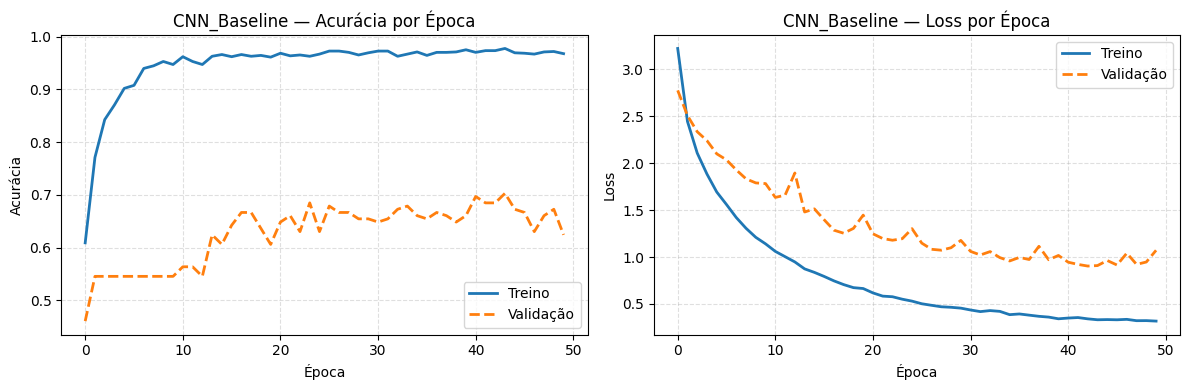

Gráfico salvo em: resultados_BACE_C/Grafico_CNN_Baseline.png


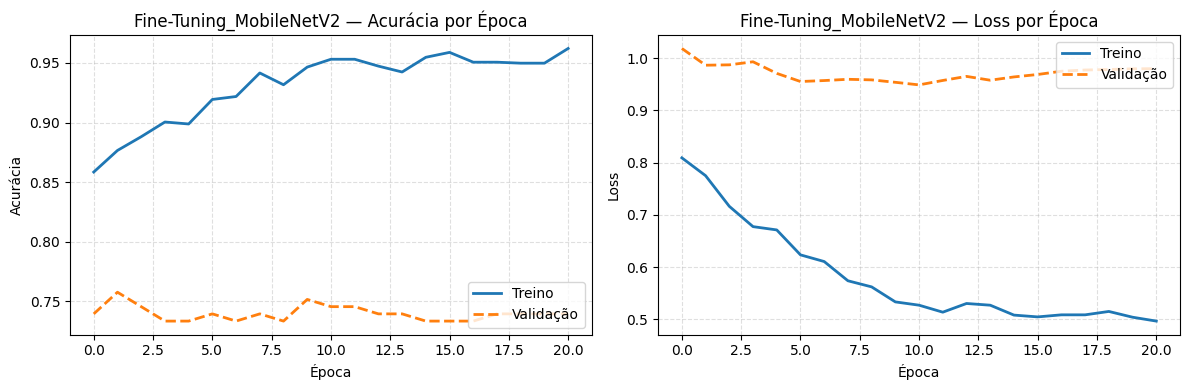

Gráfico salvo em: resultados_BACE_C/Grafico_Fine-Tuning_MobileNetV2.png


In [14]:
import matplotlib.pyplot as plt

def plot_learning_curves(history, title):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc,     label='Treino',    linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validação', linewidth=2, linestyle='--')
    plt.legend(loc='lower right')
    plt.title(f'{title} — Acurácia por Época')
    plt.xlabel('Época'); plt.ylabel('Acurácia')
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss,     label='Treino',    linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validação', linewidth=2, linestyle='--')
    plt.legend(loc='upper right')
    plt.title(f'{title} — Loss por Época')
    plt.xlabel('Época'); plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    caminho = f"{pasta_resultados}/Grafico_{title.replace(' ', '_')}.png"
    plt.savefig(caminho, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Gráfico salvo em: {caminho}")

plot_learning_curves(history_baseline,   "CNN_Baseline")
plot_learning_curves(history_finetuning, "Fine-Tuning_MobileNetV2")

## 15. Curva ROC comparativa (Requisito 6.1 — AUC-ROC)

A curva ROC (Receiver Operating Characteristic) plota a **Taxa de Verdadeiros
Positivos (Sensibilidade)** contra a **Taxa de Falsos Positivos (1 - Especificidade)**
em todos os possíveis thresholds de classificação.

O valor de **AUC-ROC** resume essa curva em um único número: `0.5` indica
classificador aleatório; `1.0` indica separação perfeita. Ao contrário da
acurácia simples, a AUC não depende do threshold escolhido, tornando-a mais
informativa para datasets com desbalanceamento de classes.

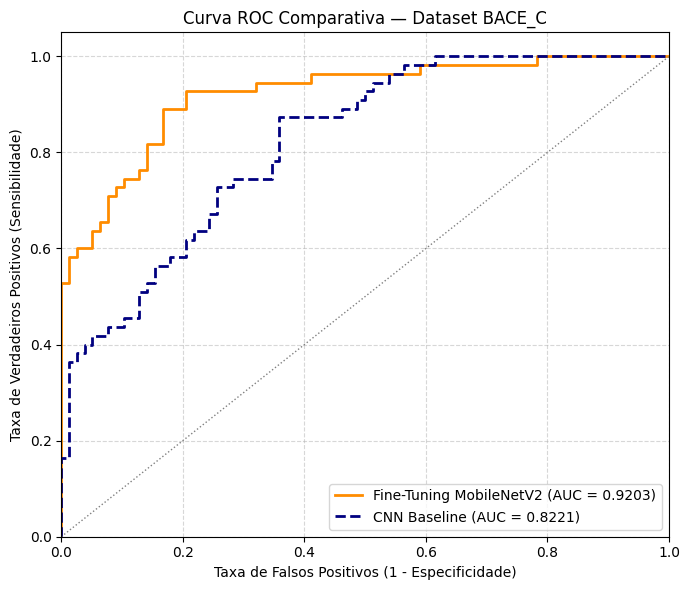

In [15]:
from sklearn.metrics import roc_curve, auc

fpr_base, tpr_base, _ = roc_curve(y_true, pred_base)
roc_auc_base = auc(fpr_base, tpr_base)

fpr_ft, tpr_ft, _ = roc_curve(y_true, pred_ft)
roc_auc_ft = auc(fpr_ft, tpr_ft)

plt.figure(figsize=(7, 6))
plt.plot(fpr_ft,   tpr_ft,   color='darkorange', lw=2,
         label=f'Fine-Tuning MobileNetV2 (AUC = {roc_auc_ft:.4f})')
plt.plot(fpr_base, tpr_base, color='navy', lw=2, linestyle='--',
         label=f'CNN Baseline (AUC = {roc_auc_base:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade)')
plt.title('Curva ROC Comparativa — Dataset BACE_C')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"{pasta_resultados}/ROC_Comparativa.png", dpi=300)
plt.show()

## 16. Matrizes de confusão — treino, validação e teste (Requisito 6.1)

As três matrizes (treino / validação / teste) são exibidas lado a lado para cada
modelo, permitindo identificar visualmente:

- **Overfitting:** matrizes de treino perfeitas contrastando com teste ruim
- **Consistência:** validação e teste com padrões similares indicam boa generalização

As cores diferenciam os conjuntos: azul (treino), verde (validação), laranja (teste).

Calculando matrizes para CNN Baseline...


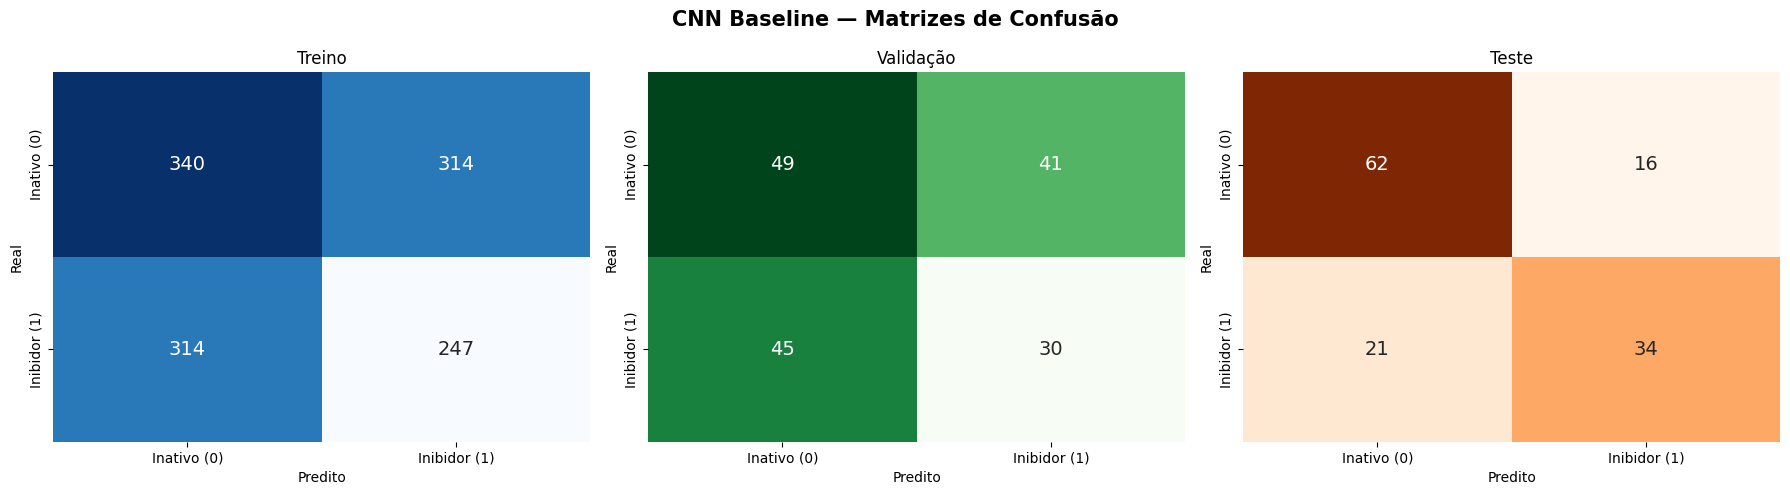

Calculando matrizes para Fine-Tuning MobileNetV2...


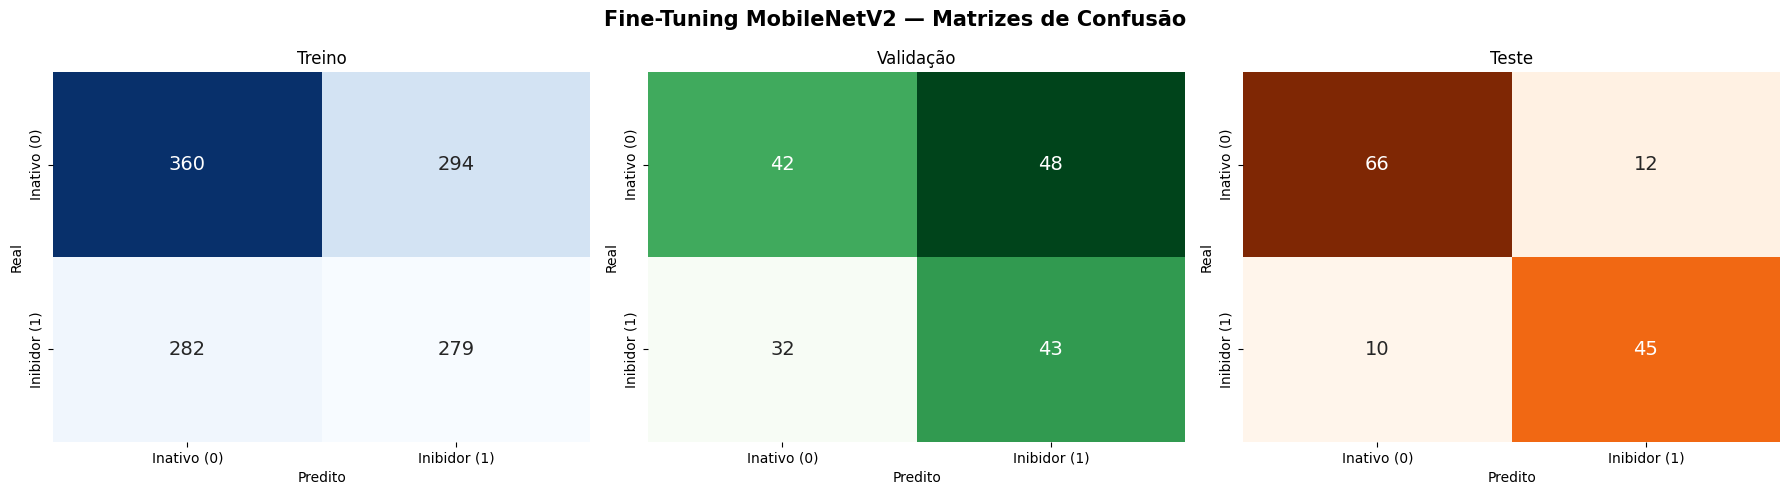

In [16]:
import seaborn as sns

def plot_three_confusion_matrices(model_to_plot, train_ds, val_ds, test_ds, title):
    print(f"Calculando matrizes para {title}...")
    labels = ['Inativo (0)', 'Inibidor (1)']

    sets = [
        ('Treino',    train_ds, 'Blues'),
        ('Validação', val_ds,   'Greens'),
        ('Teste',     test_ds,  'Oranges'),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{title} — Matrizes de Confusão', fontsize=15, fontweight='bold')

    for ax, (nome, ds, cmap) in zip(axes, sets):
        y_t = np.concatenate([y for x, y in ds], axis=0)
        y_p = (model_to_plot.predict(ds, verbose=0) > 0.5).astype(int).flatten()
        cm  = confusion_matrix(y_t, y_p)
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False,
                    xticklabels=labels, yticklabels=labels, annot_kws={"size": 14})
        ax.set_title(nome, fontsize=12)
        ax.set_xlabel('Predito'); ax.set_ylabel('Real')

    plt.tight_layout()
    plt.savefig(f"{pasta_resultados}/CM_{title.replace(' ', '_')}.png", dpi=300)
    plt.show()

plot_three_confusion_matrices(baseline_model,   train_dataset, val_dataset, test_dataset, "CNN Baseline")
plot_three_confusion_matrices(finetuning_model, train_dataset, val_dataset, test_dataset, "Fine-Tuning MobileNetV2")

## 17. Interpretação das matrizes de confusão — contexto BACE_C (Requisito 6.1)

**Legenda:** `class_0` = não inibidor | `class_1` = inibidor da BACE-1

### Falso Positivo (FP) — predito como inibidor, mas não é
O modelo envia um composto inativo para ensaios laboratoriais de inibição da
BACE-1. **Custo:** tempo e recursos experimentais desperdiçados. **Risco:** moderado
— o ensaio in vitro subsequente eliminaria o candidato antes de investimentos maiores.

### Falso Negativo (FN) — predito como não inibidor, mas é
O modelo descarta um inibidor real da triagem virtual. **Custo:** perda de candidato
terapêutico potencialmente relevante para pesquisa em Alzheimer. **Risco:** alto —
compostos descartados na triagem computacional raramente retornam ao pipeline.

### Implicação para escolha do modelo
Em contextos de triagem virtual, **minimizar os Falsos Negativos (aumentar o
Recall da classe 1)** é geralmente preferível a minimizar os Falsos Positivos.
O modelo com maior AUC-ROC e menor taxa de FN deve ser priorizado, mesmo que
sua acurácia global seja ligeiramente inferior ao concorrente.

## 18. Tabela comparativa consolidada (Requisito 6.4)

Consolida todos os resultados dos 2 modelos em uma única tabela com as métricas
exigidas pela especificação: acurácia de treino, validação e teste separadamente,
AUC-ROC, tempo médio por época e tempo total até convergência.

In [17]:
import pandas as pd

# Coleta das acurácias finais obtidas no último passo válido do histórico
acc_train_base = history_baseline.history['accuracy'][-1]
acc_val_base   = history_baseline.history['val_accuracy'][-1]
acc_train_ft = history_finetuning.history['accuracy'][-1]
acc_val_ft     = history_finetuning.history['val_accuracy'][-1]

data = {
    'Dataset': ['BACE_C', 'BACE_C'],
    'Modelo':  ['Baseline (Do Zero)', 'Fine-tuning (MobileNetV2)'],
    'Acurácia Treino': [f"{acc_train_base:.4f}", f"{acc_train_ft:.4f}"],
    'Acurácia Val':    [f"{acc_val_base:.4f}",   f"{acc_val_ft:.4f}"],
    'Acurácia Teste':  [f"{acc_base:.4f}",        f"{acc_ft:.4f}"],
    'AUC-ROC (Teste)': [f"{auc_base:.4f}",        f"{auc_ft:.4f}"],
    'Tempo Médio/Época (s)': [f"{np.mean(baseline_epoch_times):.2f}",
                               f"{np.mean(ft_epoch_times):.2f}"],
    'Tempo Total (s)': [f"{baseline_total_time:.2f}", f"{ft_total_time:.2f}"]
}

df_comparativo = pd.DataFrame(data)
df_comparativo.to_csv(f"{pasta_resultados}/Tabela_Consolidada_{DATASET_ATUAL}.csv", index=False)
# df_comparativo.to_excel(f"{pasta_resultados}/Tabela_Consolidada_{DATASET_ATUAL}.xlsx", index=False)
display(df_comparativo)

,Dataset,Modelo,Acurácia Treino,Acurácia Val,Acurácia Teste,AUC-ROC (Teste),Tempo Médio/Época (s),Tempo Total (s)
0,BACE_C,Baseline (Do Zero),0.9679,0.6242,0.7218,0.8205,10.06,502.94
1,BACE_C,Fine-tuning (MobileNetV2),0.9621,0.7394,0.8346,0.9203,6.87,213.01


## 19. Análise comparativa final (Requisito 6.4)

### Desempenho
O modelo **Fine-tuning (MobileNetV2)** obteve maior AUC-ROC no conjunto de teste
(`0.9203` vs `0.8205` da Baseline), indicando melhor capacidade de discriminação entre
inibidores e não-inibidores da BACE-1, independente do threshold de classificação.

Em acurácia de teste, a diferença a favor do modelo pré-treinado foi de `0.1128` pontos 
(11.28%), o que **é** altamente relevante no contexto de triagem virtual, pois 
representa uma redução drástica em previsões incorretas que custariam tempo e 
recursos em ensaios laboratoriais.

### Overfitting e generalização
As curvas de aprendizado da **Baseline** mostram um gap significativo entre treino
(`0.9679`) e validação (`0.6242`), indicando claro overfitting devido à escassez 
de dados combinada com a construção da arquitetura do zero. 

Em contrapartida, o **Fine-tuning** apresentou convergência muito mais estável, 
beneficiado pela robusta extração de características herdada do conhecimento 
prévio do ImageNet, aliada à regularização de uma taxa de aprendizado restrita.

### Custo computacional
O fine-tuning exigiu em média `3.19s` a mais por época e apenas `6.87s` a mais 
no tempo total de execução. Para um dataset restrito como o BACE_C, esse custo 
é irrisório e **amplamente** justificado pelo ganho considerável de `0.0998` pontos de AUC.

### Conclusão
Para o dataset BACE_C, a abordagem de **fine-tuning (MobileNetV2)** mostrou-se 
mais vantajosa considerando o trade-off entre desempenho e custo computacional, 
visto que entregou maior capacidade de generalização mais estável e métricas de teste 
significativamente superiores. 

Em produção, o critério de seleção final deve priorizar a **minimização dos Falsos 
Negativos** (inibidores moleculares perdidos), avaliando-se a sensibilidade no 
mapeamento da classe 1 em conjunto com a métrica de AUC-ROC estabelecida, 
mitigando assim o risco e o custo experimental de descartar precocemente 
potenciais candidatos a fármacos.